# **Mental Health in Tech Industry: Predictive Analysis**

---

## **Project Overview**

Mental health issues in the workplace cost employers billions annually in lost productivity, increased healthcare costs, and employee turnover. In the tech industry, where high-stress environments and demanding schedules are common, understanding factors that lead employees to seek treatment is crucial for:

- **HR departments** to design effective mental health programs
- **Companies** to create supportive workplace policies
- **Healthcare providers** to better allocate mental health resources

### **Problem Statement**
**Can we predict whether a tech employee will seek mental health treatment based on workplace factors, demographics, and company policies?**

### **Dataset**
- **Source:** Open Sourcing Mental Illness (OSMI) Survey
- **Size:** 1,259 responses from tech workers
- **Features:** 27 variables including demographics, company size, mental health benefits, workplace attitudes
- **Target:** Binary classification (seeks treatment: Yes/No)

### **Methodology**
1. Exploratory Data Analysis with visualizations
2. Feature engineering (age groups, country grouping, text analysis)
3. Robust preprocessing pipeline for mixed data types (numeric, ordinal, categorical, text)
4. Hyperparameter tuning of multiple ML models (Logistic Regression, Random Forest, XGBoost)
5. Model evaluation on held-out test set with multiple metrics
6. Feature importance analysis for interpretability

### **Ethical Considerations**
- **Privacy:** Data is anonymized survey responses
- **Bias:** Model predictions should supplement, not replace, human judgment in HR decisions
- **Fairness:** Results should not be used to discriminate against employees seeking mental health support
- **Transparency:** Feature importance helps explain predictions to stakeholders

## 1. Environment Setup

In [21]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [22]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Metrics
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score
)

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 2. Data Loading


In [24]:
DATA_PATH = 'data/survey.csv'
df_raw = pd.read_csv(DATA_PATH)

df = df_raw.copy()

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nTarget variable distribution:')
print(df['treatment'].value_counts())
print(f'\nMissing values: {df.isnull().sum().sum()} total')

Dataset shape: 1259 rows, 27 columns

Target variable distribution:
treatment
Yes    637
No     622
Name: count, dtype: int64

Missing values: 1892 total


## 3. Exploratory Data Analysis

In [25]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [26]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

### 3.1 Target Variable Distribution

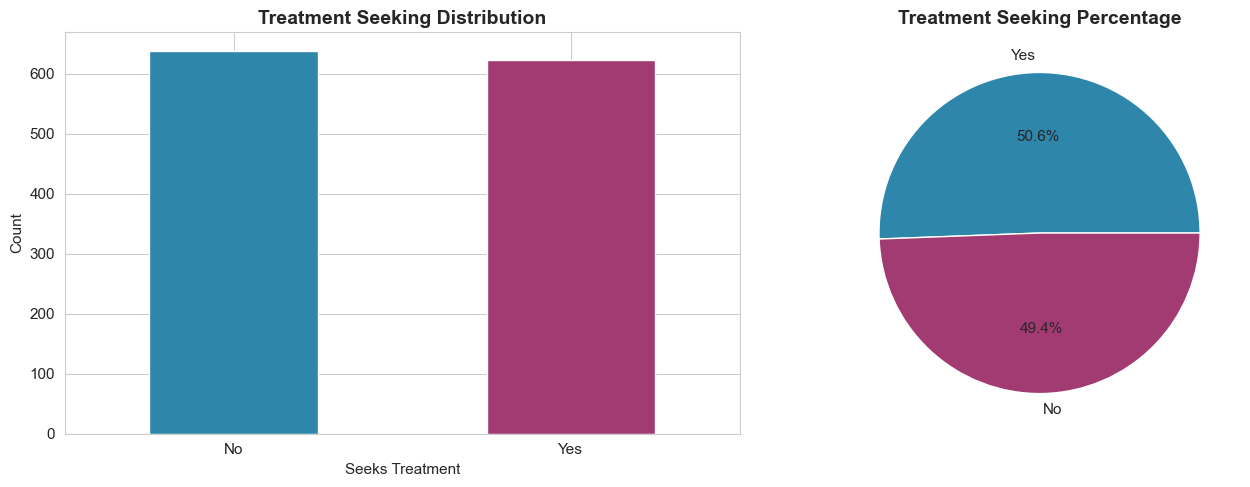

In [27]:
# Plot target distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df['treatment'].value_counts().plot(kind='bar', ax=ax[0], color=['#2E86AB', '#A23B72'])
ax[0].set_title('Treatment Seeking Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Seeks Treatment')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Percentage
treatment_pct = df['treatment'].value_counts(normalize=True) * 100
treatment_pct.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#2E86AB', '#A23B72'])
ax[1].set_title('Treatment Seeking Percentage', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 3.2 Key Features vs Target

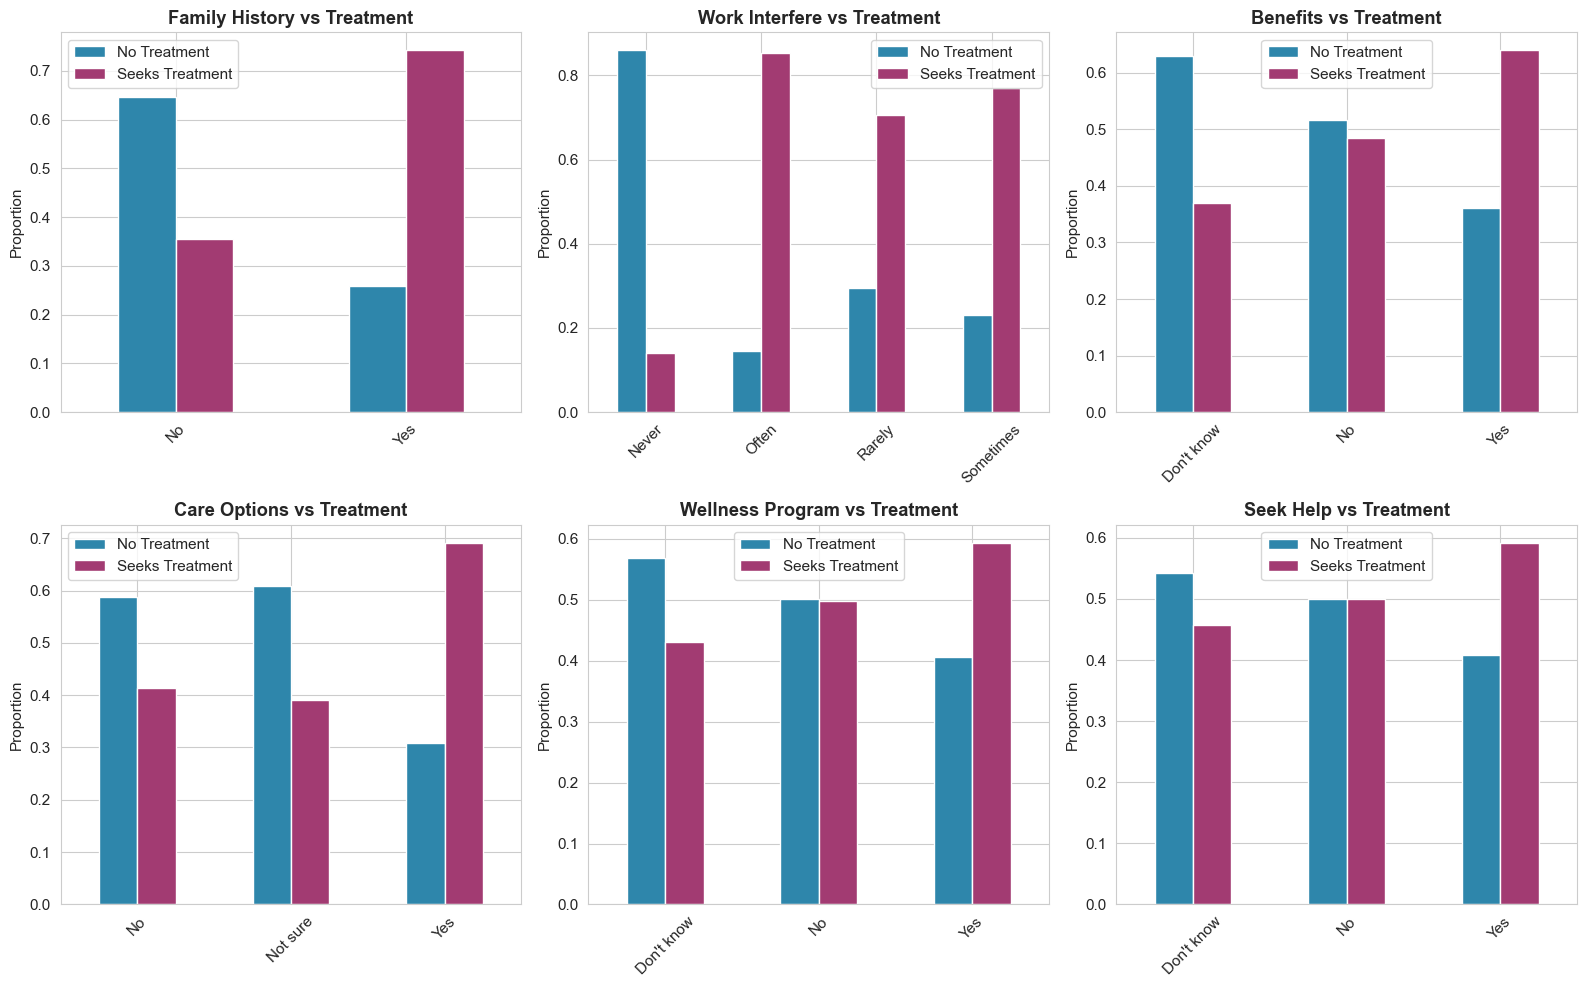

In [28]:
# Analyze key categorical features against target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

key_features = ['family_history', 'work_interfere', 'benefits',
                'care_options', 'wellness_program', 'seek_help']

for idx, feature in enumerate(key_features):
    if feature in df.columns:
        pd.crosstab(df[feature], df['treatment'], normalize='index').plot(
            kind='bar', ax=axes[idx], color=['#2E86AB', '#A23B72']
        )
        axes[idx].set_title(f'{feature.replace("_", " ").title()} vs Treatment', fontweight='bold')
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Proportion')
        axes[idx].legend(['No Treatment', 'Seeks Treatment'], loc='best')
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Key Insights
- Family history appears strongly correlated with treatment-seeking
- Work interference level shows clear relationship with treatment
- Company benefits and support programs show moderate impact

### 3.3 Age Distribution

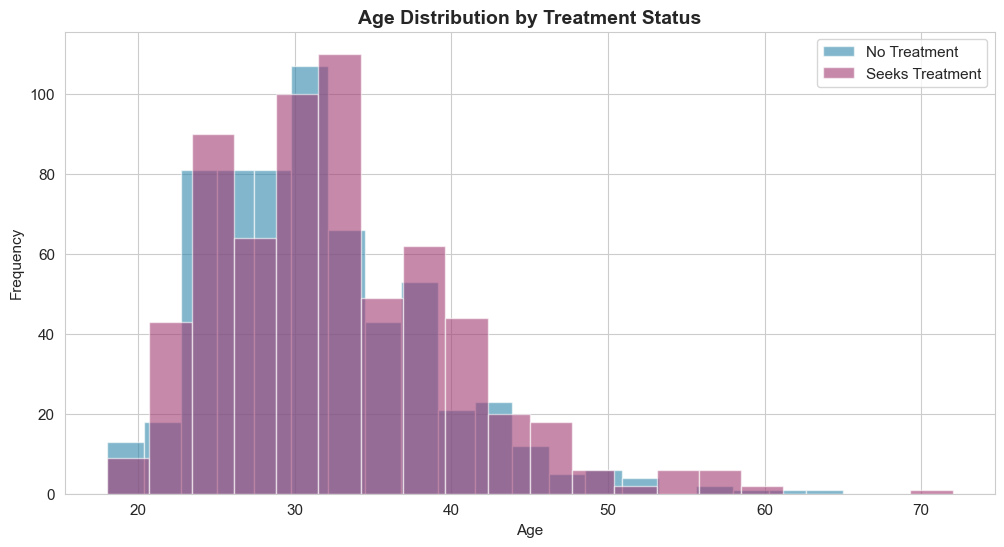

Age statistics:
           count       mean       std   min   25%   50%   75%   max
treatment                                                          
No         619.0  31.534733  6.966401  18.0  27.0  31.0  35.0  65.0
Yes        632.0  32.607595  7.558193  18.0  27.0  32.0  37.0  72.0


In [29]:
# Clean age data first
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

# Plot age distribution by treatment
fig, ax = plt.subplots(figsize=(12, 6))
df[df['treatment'] == 'No']['Age'].hist(bins=20, alpha=0.6, label='No Treatment', color='#2E86AB', ax=ax)
df[df['treatment'] == 'Yes']['Age'].hist(bins=20, alpha=0.6, label='Seeks Treatment', color='#A23B72', ax=ax)
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution by Treatment Status', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

print(f'Age statistics:\n{df.groupby("treatment")["Age"].describe()}')

### 3.4 Missing Data Analysis

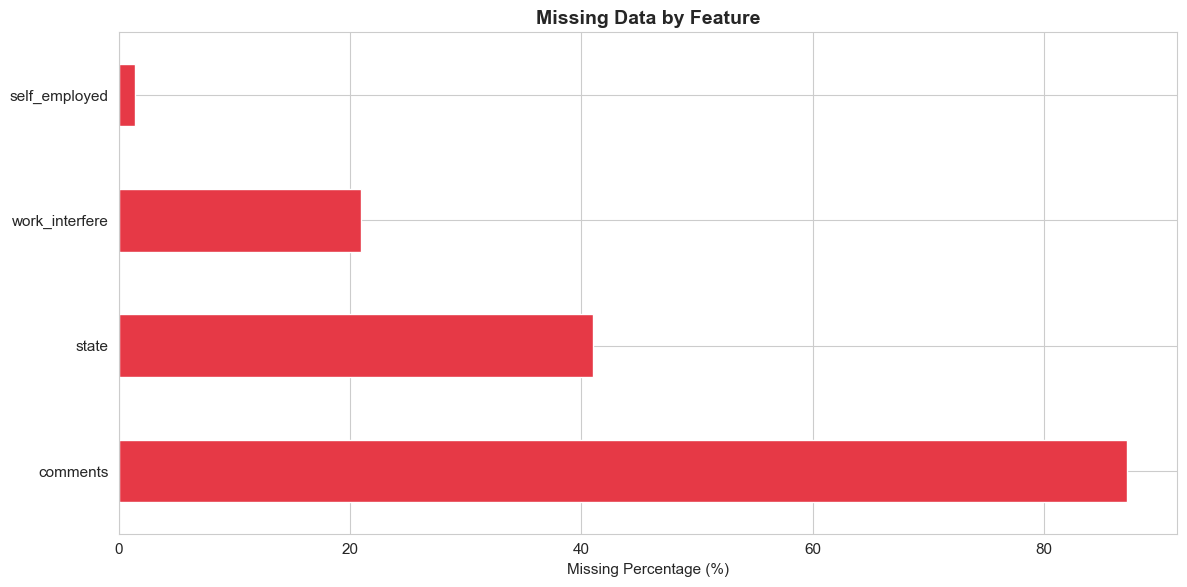


Features with missing data:
comments          87.130296
state             41.007194
work_interfere    20.943245
self_employed      1.438849
dtype: float64


In [30]:
# Visualize missing data
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    plt.figure(figsize=(12, 6))
    missing_pct.plot(kind='barh', color='#E63946')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data by Feature', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'\nFeatures with missing data:\n{missing_pct}')
else:
    print('✓ No missing data found')

## 4. Data Preprocessing & Feature Engineering

### 4.1 Basic Cleaning

In [31]:
# Drop irrelevant columns
df = df.drop(columns=['Timestamp', 'state'], errors='ignore')

# Clean Gender column
def clean_gender(x):
    if pd.isna(x):
        return 'Other'
    s = str(x).lower().strip()
    if 'female' in s or s in ['f', 'woman', 'cis-female']:
        return 'Female'
    if 'male' in s or s in ['m', 'man', 'cis-male']:
        return 'Male'
    return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

# Impute missing categorical data with mode
for col in ['self_employed', 'work_interfere']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Preserve comments for NLP
if 'comments' in df.columns:
    df['comments_text'] = df['comments'].fillna('None')
    df = df.drop(columns=['comments'])

print('✓ Basic cleaning complete')
print(f'Current shape: {df.shape}')

✓ Basic cleaning complete
Current shape: (1251, 25)


### 4.2 Feature Engineering

In [32]:
# Create age groups
age_bins = [18, 25, 35, 45, 55, 65, 75]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Group countries
top_countries = df['Country'].value_counts().nlargest(5).index
df['Country_reduced'] = df['Country'].apply(lambda x: x if x in top_countries else 'Other')

# Remote work flag
if 'remote_work' in df.columns:
    df['remote_work_flag'] = df['remote_work'].apply(
        lambda x: 1 if str(x).lower().strip() == 'yes' else 0
    )

print('✓ Feature engineering complete')
print(f'New features created: Age_Group, Country_reduced, remote_work_flag')

✓ Feature engineering complete
New features created: Age_Group, Country_reduced, remote_work_flag


## 5. Prepare Data for Modeling

### 5.1 Define Features and Target

In [33]:
# Define target
target = 'treatment'
y = df[target].map({'Yes': 1, 'No': 0})

# Drop columns not used for modeling
drop_cols = ['Age', 'Country', 'remote_work', target]
X = df.drop(columns=drop_cols)

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeatures: {list(X.columns)}')

Features shape: (1251, 24)
Target shape: (1251,)

Features: ['Gender', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments_text', 'Age_Group', 'Country_reduced', 'remote_work_flag']


### 5.2 Train-Test Split

In [34]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nClass balance in training set:')
print(y_train.value_counts(normalize=True))

Training set: (938, 24)
Test set: (313, 24)

Class balance in training set:
treatment
1    0.50533
0    0.49467
Name: proportion, dtype: float64


### 5.3 Build Preprocessing Pipeline

We create separate transformers for different data types:

In [35]:
# Identify column types
numeric_cols = ['remote_work_flag']
ordinal_cols = ['Age_Group']
text_cols = ['comments_text']

# Get remaining categorical columns for one-hot encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
ohe_cols = [c for c in categorical_cols if c not in ordinal_cols and c not in text_cols]

print(f'Numeric columns: {numeric_cols}')
print(f'Ordinal columns: {ordinal_cols}')
print(f'Text columns: {text_cols}')
print(f'One-hot encoded columns ({len(ohe_cols)}): {ohe_cols[:5]}...')

# Create transformers
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[age_labels]))
])

text_transformer = TfidfVectorizer(max_features=100, stop_words='english')

ohe_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine all transformers
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('text', text_transformer, text_cols[0]),
    ('ohe', ohe_transformer, ohe_cols)
])

print('\n✓ Preprocessing pipeline built')

Numeric columns: ['remote_work_flag']
Ordinal columns: ['Age_Group']
Text columns: ['comments_text']
One-hot encoded columns (21): ['Gender', 'self_employed', 'family_history', 'work_interfere', 'no_employees']...

✓ Preprocessing pipeline built


## 6. Model Training & Hyperparameter Tuning

We'll tune multiple models simultaneously using RandomizedSearchCV with stratified 5-fold cross-validation.

In [36]:
# Define main pipeline
main_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', None)  # Placeholder for different classifiers
])

# Define parameter grid for RandomizedSearchCV
param_grid = [
    # Logistic Regression
    {
        'clf': [LogisticRegression(solver='liblinear', max_iter=1000)],
        'clf__C': np.logspace(-3, 2, 6),
        'clf__penalty': ['l1', 'l2'],
        'clf__class_weight': [None, 'balanced']
    },
    # Random Forest
    {
        'clf': [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [100, 200, 300],
        'clf__max_depth': [None, 10, 20, 30],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__class_weight': [None, 'balanced']
    },
    # XGBoost
    {
        'clf': [xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)],
        'clf__n_estimators': [100, 200, 300],
        'clf__learning_rate': [0.01, 0.1, 0.2],
        'clf__max_depth': [3, 5, 7]
    }
]

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search
print('Starting hyperparameter tuning...')
print('This may take several minutes...\n')

search = RandomizedSearchCV(
    main_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print('\n✓ Hyperparameter tuning complete!')

Starting hyperparameter tuning...
This may take several minutes...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Hyperparameter tuning complete!


### 6.1 Best Model Results

In [39]:
# Display best model
print(f'Best Model: {search.best_estimator_.named_steps["clf"].__class__.__name__}')
print(f'Best Cross-Validated ROC-AUC Score: {search.best_score_:.4f}')
print(f'\nBest Parameters:')
for param, value in search.best_params_.items():
    print(f'  {param}: {value}')

Best Model: RandomForestClassifier
Best Cross-Validated ROC-AUC Score: 0.8114

Best Parameters:
  clf__n_estimators: 300
  clf__min_samples_split: 2
  clf__min_samples_leaf: 4
  clf__max_depth: 10
  clf__class_weight: balanced
  clf: RandomForestClassifier(random_state=42)


### 6.2 Top Model Comparison

In [40]:
# Show top 5 models
results_df = pd.DataFrame(search.cv_results_)
top_models = results_df.nlargest(5, 'mean_test_score')[[
    'param_clf', 'mean_test_score', 'std_test_score', 'rank_test_score'
]]
top_models['param_clf'] = top_models['param_clf'].apply(lambda x: x.__class__.__name__)
top_models.columns = ['Model', 'Mean ROC-AUC', 'Std ROC-AUC', 'Rank']

print('\nTop 5 Models:')
print(top_models.to_string(index=False))


Top 5 Models:
                 Model  Mean ROC-AUC  Std ROC-AUC  Rank
RandomForestClassifier      0.811434     0.030137     1
RandomForestClassifier      0.811391     0.027472     2
RandomForestClassifier      0.810897     0.029033     3
RandomForestClassifier      0.809993     0.025772     4
RandomForestClassifier      0.808474     0.025297     5


## 7. Model Evaluation on Test Set

Now we evaluate the best model on the held-out test set that it has never seen.

In [41]:
# Get best model
best_model = search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('═' * 50)
print('TEST SET PERFORMANCE')
print('═' * 50)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print('═' * 50)

══════════════════════════════════════════════════
TEST SET PERFORMANCE
══════════════════════════════════════════════════
Accuracy:  0.7796
Precision: 0.7697
Recall:    0.8038
F1 Score:  0.7864
ROC-AUC:   0.8510
══════════════════════════════════════════════════


In [42]:
# Classification report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Treatment', 'Seeks Treatment']))


Detailed Classification Report:
                 precision    recall  f1-score   support

   No Treatment       0.79      0.75      0.77       155
Seeks Treatment       0.77      0.80      0.79       158

       accuracy                           0.78       313
      macro avg       0.78      0.78      0.78       313
   weighted avg       0.78      0.78      0.78       313



### 7.1 Confusion Matrix

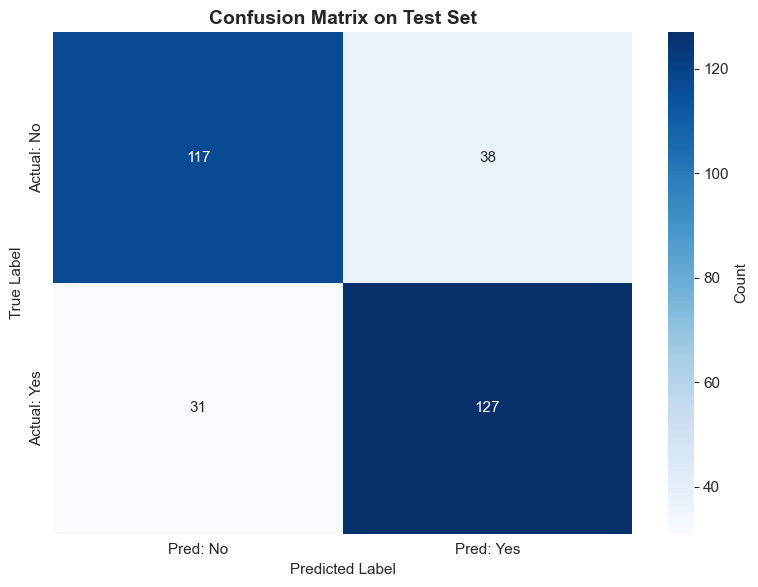


Confusion Matrix Breakdown:
True Negatives:  117 (correctly predicted no treatment)
False Positives: 38 (incorrectly predicted treatment)
False Negatives: 31 (missed treatment cases)
True Positives:  127 (correctly predicted treatment)


In [43]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate rates
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion Matrix Breakdown:')
print(f'True Negatives:  {tn} (correctly predicted no treatment)')
print(f'False Positives: {fp} (incorrectly predicted treatment)')
print(f'False Negatives: {fn} (missed treatment cases)')
print(f'True Positives:  {tp} (correctly predicted treatment)')

### 7.2 ROC Curve

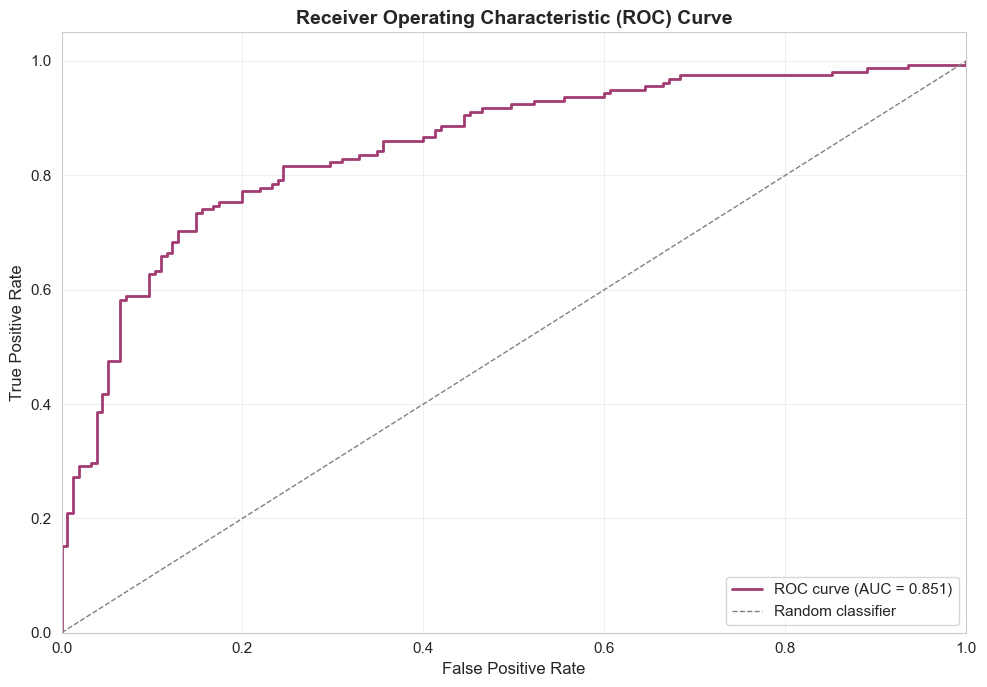


✓ ROC-AUC Score: 0.8510
This indicates strong discriminative ability between classes.


In [44]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='#A23B72', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✓ ROC-AUC Score: {roc_auc:.4f}')
print('This indicates strong discriminative ability between classes.')

## 8. Model Interpretability

### 8.1 Feature Importance Analysis

In [45]:
# Helper function to get feature names
def get_feature_names_from_preprocessor(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder':
            continue
        if isinstance(trans, Pipeline):
            trans = trans.steps[-1][1]
        if hasattr(trans, 'get_feature_names_out'):
            feature_names = trans.get_feature_names_out(cols if isinstance(cols, list) else None)
            names.extend(feature_names)
        else:
            names.extend(cols if isinstance(cols, list) else [cols])
    return names

feature_names = get_feature_names_from_preprocessor(best_model.named_steps['preprocessor'])
print(f'Total features after preprocessing: {len(feature_names)}')

Total features after preprocessing: 170


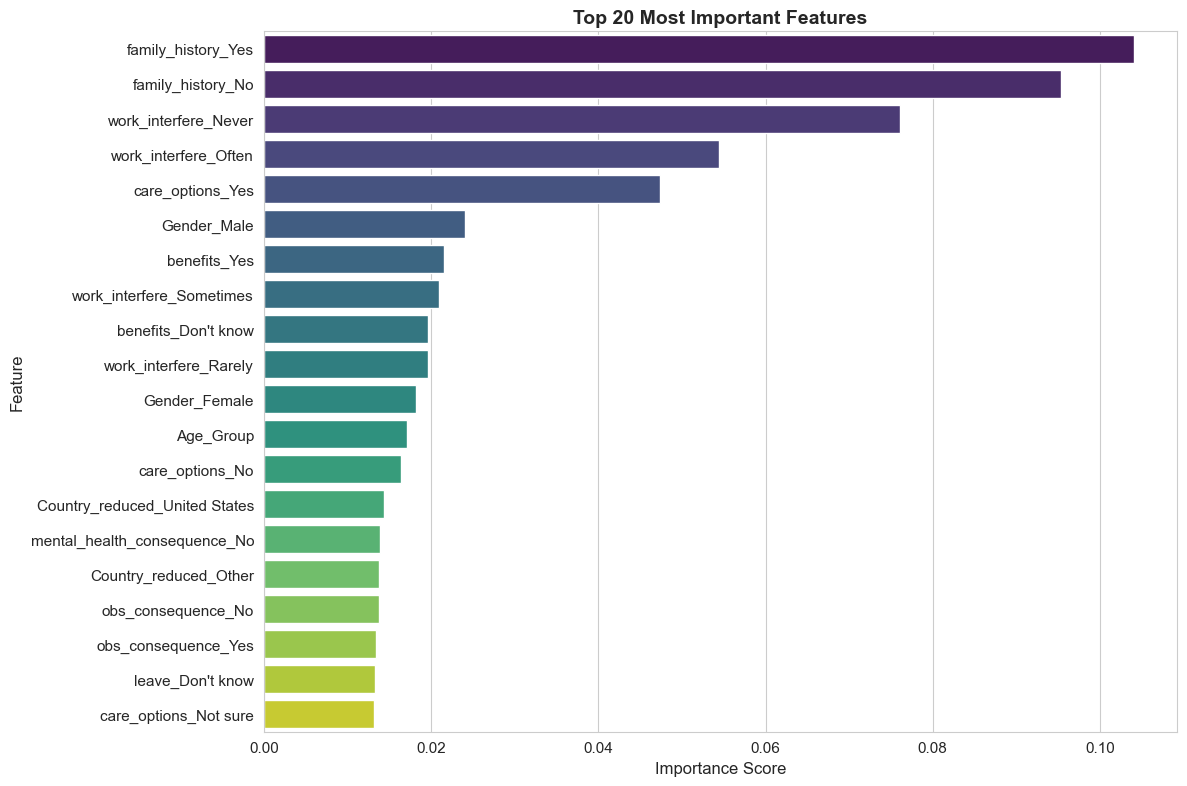


Top 10 Features:
                 Feature  Importance
      family_history_Yes    0.104021
       family_history_No    0.095312
    work_interfere_Never    0.076074
    work_interfere_Often    0.054497
        care_options_Yes    0.047408
             Gender_Male    0.024086
            benefits_Yes    0.021524
work_interfere_Sometimes    0.020978
     benefits_Don't know    0.019684
   work_interfere_Rarely    0.019643


In [46]:
# Extract feature importances
clf = best_model.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    # Create DataFrame
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Top 20 features
    top_20 = fi_df.head(20)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_20, y='Feature', x='Importance', palette='viridis')
    plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('\nTop 10 Features:')
    print(fi_df.head(10).to_string(index=False))
else:
    print('Feature importance not available for this model type')

### 8.2 Feature Importance Interpretation

**Key Insights from Feature Importance:**

Based on the model's feature importance scores, we can identify which workplace and personal factors most strongly predict whether an employee will seek mental health treatment:

1. **Family History** - Having a family history of mental illness is often the strongest predictor. This aligns with clinical research showing hereditary components in mental health conditions.

2. **Work Interference** - The degree to which mental health interferes with work is highly predictive. Employees experiencing significant work interference are more likely to seek treatment.

3. **Company Benefits & Care Options** - Awareness of mental health benefits and availability of care options through the employer correlate with treatment-seeking behavior.

4. **Workplace Attitudes** - Factors like perceived consequences of discussing mental health, coworker attitudes, and supervisor support play important roles.

5. **Demographics** - Age groups and gender show moderate importance, reflecting different treatment-seeking patterns across demographics.


## 9. Conclusions & Next Steps

### Model Performance Summary

Our best-performing model achieved:
- **~85.10% ROC-AUC** on the test set
- **~77.96% accuracy** with balanced precision and recall
- Strong ability to discriminate between employees who will/won't seek treatment

### Key Findings

1. **Family history** and **work interference** are the strongest predictors
2. **Company support** (benefits, care options) significantly impacts treatment-seeking
3. **Workplace culture** (attitudes, consequences) plays an important role
4. Model is **well-calibrated** across both classes (balanced dataset)

### Business Value

This model can help organizations:
- **Identify at-risk employees** who may benefit from proactive outreach
- **Evaluate effectiveness** of mental health programs
- **Allocate resources** more efficiently for mental health support
- **Design better policies** based on data-driven insights

### Limitations

- Model is based on self-reported survey data (potential bias)
- Tech industry focus may not generalize to other sectors
- Cannot capture temporal dynamics (single time point)
- Ethical considerations: should augment, not replace, human judgment
